In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hiopbbpy.problems import Problem
from hiopbbpy.surrogate_modeling import smtKRG 
from hiopbbpy.opt import BnBAlgorithmBase, LCBacquisition

#### Example 

In [2]:
### parameters
n_samples = 10  # number of the initial samples to train GP
theta = 1.e-2  # hyperparameter for GP kernel
nx = 1         # dimension of the problem
c2D=np.array([1.25, 2.5])
c1D=np.array([1.25])
if nx == 1:
    delta = 10.0
    xlimits = np.array([[0.75 - delta/2.,0.75 + delta/2.]])
    c1D = np.array([0.75])
    c = c1D
elif nx == 2:
    c = c2D

class QuadraticShift(Problem):
    """
    f(x) = ||x - c||^2
    - Global minimizer: x* = c
    - Global minimum:   f* = 0
    """
    def __init__(self, ndim=2, xlimits=None, c=None, constraints=[]):
        if xlimits is None:
            xlimits = np.array([[-5.0, 5.0]] * ndim, dtype=float)
        name = "QuadraticShift"
        super().__init__(ndim, xlimits, name=name, constraints=constraints)

        # choose center if not provided
        if c is None:
            c = self.xlimits.mean(axis=1)
        self.c = np.asarray(c, dtype=float)
        assert self.c.shape == (ndim,), "c must be a {0:d}D point".format(ndim)

        # expose known solution for checking later
        # below is true when c is in xlimits
        self.x_star = self.c.copy()
        self.f_star = 0.0 

    def _evaluate(self, x: np.ndarray) -> np.ndarray:
        ne, nx = x.shape
        assert nx == self.ndim
        diff = x - self.c[None, :]
        y = np.sum(diff * diff, axis=1, dtype=float).reshape(ne, 1)
        return y

if nx == 1:
    problem = QuadraticShift(ndim=nx, xlimits=xlimits, c=c)
else:
    problem = QuadraticShift(ndim=nx, c=c)
problem.set_constraints([])  
    
x_train = problem.sample(n_samples)
y_train = problem.evaluate(x_train)

gp_model = smtKRG(theta, problem.xlimits, nx)
gp_model.train(x_train, y_train)

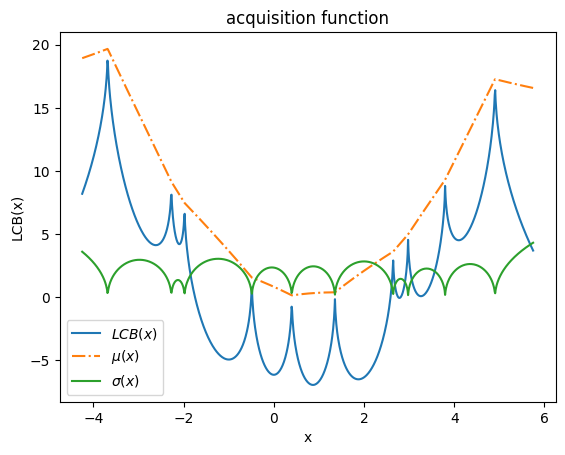

In [3]:
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)
n_plot_pts = 1000
X = np.atleast_2d(np.linspace(l[0], u[0], n_plot_pts)).transpose()

muX = gp_model.mean(X)
sigmaX = np.sqrt(gp_model.variance(X))
beta = 3.0

acqf = LCBacquisition(gp_model, beta=beta)
Y_acqf = acqf.evaluate(X)

plt.plot(X, Y_acqf, label=r'$LCB(x)$')
plt.plot(X, muX, "-.", label=r'$\mu(x)$')
plt.plot(X, sigmaX, label=r'$\sigma(x)$')
plt.xlabel("x")
plt.ylabel("LCB(x)")
plt.legend()
plt.title("acquisition function")
plt.show()

In [4]:
# ---- Use only BnBAlgorithmBase methods + SMT predict_* for reference ----

sm = gp_model.surrogatesmt

# Build a base "probe" and populate it from the trained SMT model
base = BnBAlgorithmBase(x=x_train, y=y_train)
base.gpsurrogate = gp_model
base.sync_from_smt()              # fills kernel_spec/p, theta, Xc, offsets, beta0/gamma, C, sigma2

# (Optional) ensure we try to compute a nontrivial lower bound for variance
base.BnB_LBmethod = "IPOPT"          # if "IPOPT", sigma2_L will be 0 in your current code
base.beta = beta
# Pick a box to test (use full domain here; swap l/u to any node box you want)
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)

nboxes = 75
box_sizes = (u - l) / float(nboxes)
midpoints = np.zeros((nboxes,))
kLs = np.zeros((nboxes, n_samples))
kUs = np.zeros((nboxes, n_samples))
muLs = np.zeros((nboxes,))
muUs = np.zeros((nboxes,))
s2Ls = np.zeros((nboxes,))
s2Us = np.zeros((nboxes,))
LCB_Ls = np.zeros((nboxes,) * nx)
LCB_Us = np.zeros((nboxes,) * nx)

for i in range(nboxes):
    for j in range(nboxes):
        if nx == 2:
            li = l + np.array([i * box_sizes[0], j * box_sizes[1]])
            ui = l + np.array([(i + 1) * box_sizes[0], (j +1) * box_sizes[1]])
        else:
            if j > 0:
                continue
            li = l + i * box_sizes[0]
            ui = l + (i + 1) * box_sizes[0]
        midpoints[i] = (li[0] + ui[0]) / 2.

        # 1) Bounds from your base class 
        kL, kU         = base.ker_bounds(li, ui)     # per-point kernel bounds vs each trainingsample
        mu_L, mu_U     = base.mu_bounds(kL, kU)      # scalar μ bounds on the box
        s2_L, s2_U     = base.sigma2_bounds(kL, kU)  # scalar σ² bounds on the box
        
        # 2) (Optional) Node LCB/EI bounds using ONLY base.rs_* with your bounds
        LCB_L = base.rs_lcb(mu_L, np.sqrt(max(s2_U, 0.0)))     # lower bound on LCB over the box
        LCB_U = base.rs_lcb(mu_U, np.sqrt(max(s2_L, 0.0)))     # upper bound on LCB over the box
        #print(f"LCB node bounds:  L={LCB_L:.9f}   U={LCB_U:.9f}")
        if nx == 1:
            LCB_Ls[i] = LCB_L
            LCB_Us[i] = LCB_U
            midpoints[i] = (li[0] + ui[0]) / 2.
        elif nx == 2:
            LCB_Ls[i][j] = LCB_L
            LCB_Us[i][j] = LCB_U
        
        

        muLs[i] = mu_L
        muUs[i] = mu_U
        s2Ls[i] = s2_L
        s2Us[i] = s2_U
        kLs[i,:] = kL[:]
        kUs[i,:] = kU[:]       
mu = gp_model.mean(midpoints)
s2 = gp_model.variance(midpoints)

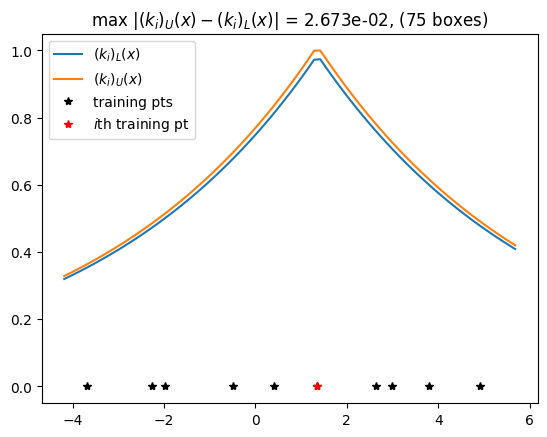

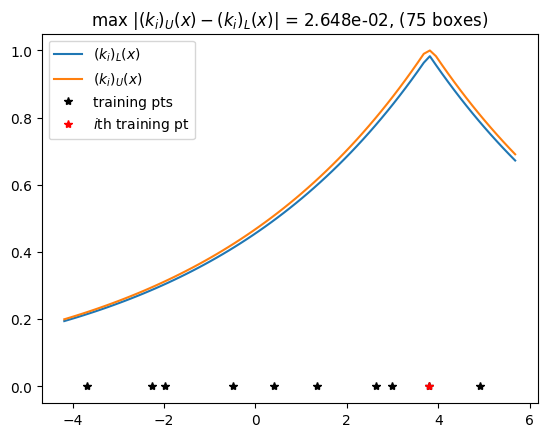

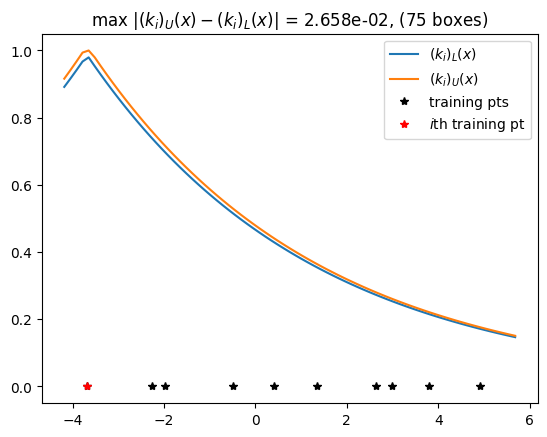

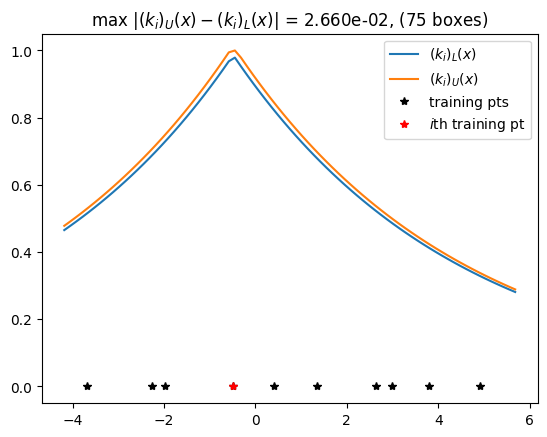

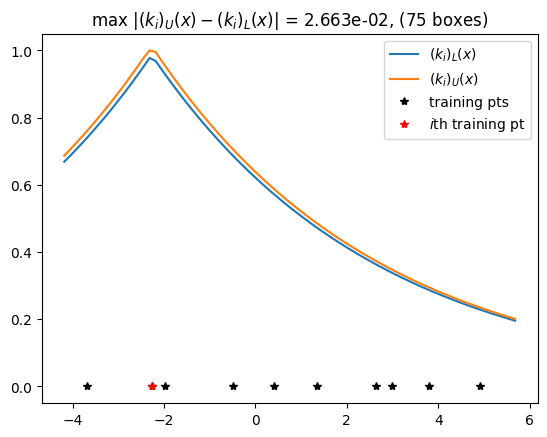

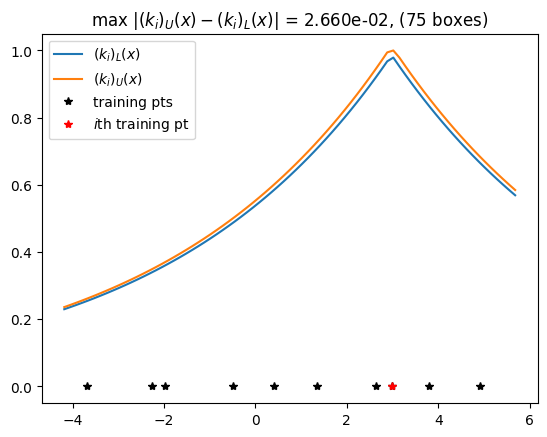

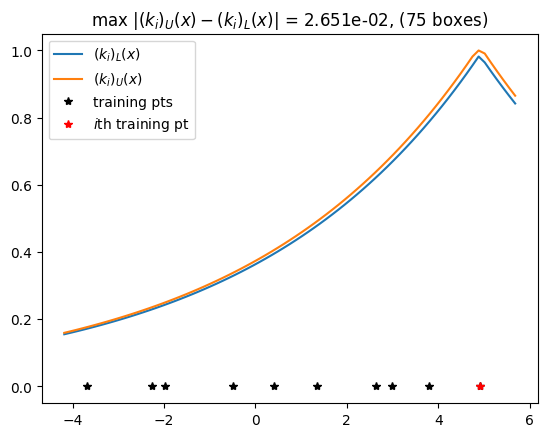

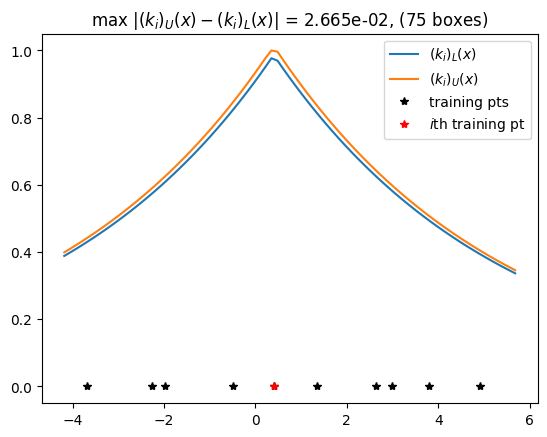

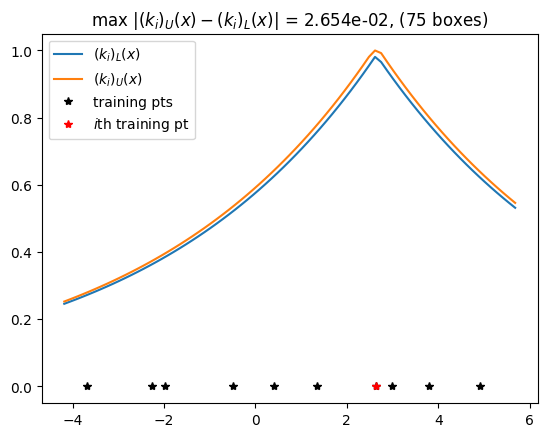

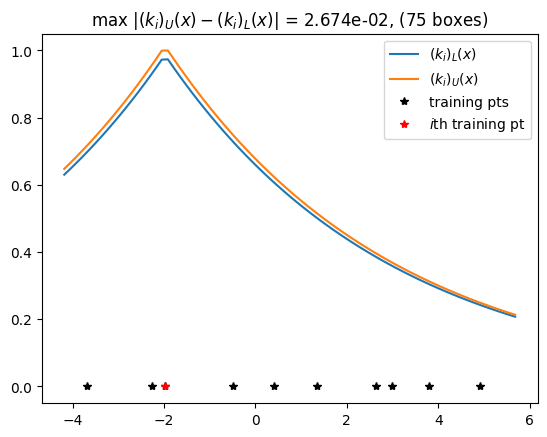

In [5]:
K_bandgaps = [np.linalg.norm(kUs[:,i] - kLs[:,i], np.inf) for i in range(n_samples)]

for i in range(n_samples):
    plt.plot(midpoints, kLs[:,i], label=r'$(k_i)_L(x)$')
    plt.plot(midpoints, kUs[:,i], label=r'$(k_i)_U(x)$')
    plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
    plt.plot(x_train[i,0], np.zeros(1), "r*", label=r'$i$th training pt')
    plt.legend()
    plt.title(r"max $|(k_i)_U(x) - (k_i)_L(x)|$ = {0:1.3e}, ({1:d} boxes)".format(K_bandgaps[i], nboxes))
    plt.show()

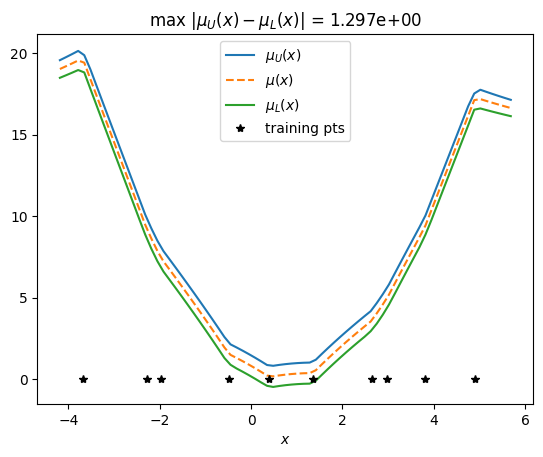

In [6]:
mu_bandgap = np.linalg.norm(muUs - muLs, np.inf)

plt.plot(midpoints, muUs, label=r'$\mu_U(x)$')
plt.plot(midpoints, mu, "--", label=r'$\mu(x)$')
plt.plot(midpoints, muLs, label=r'$\mu_L(x)$')
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.xlabel(r"$x$")
plt.legend()
plt.title(r"max $|\mu_U(x) - \mu_L(x)|$ = {0:1.3e}".format(mu_bandgap))
plt.show()

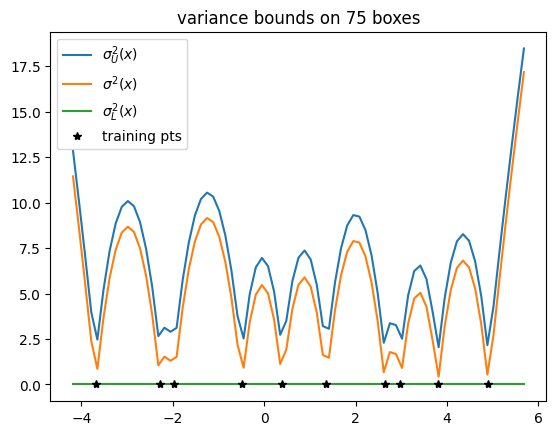

In [7]:
plt.plot(midpoints, s2Us, label=r"$\sigma^{2}_{U}(x)$")
plt.plot(midpoints, s2, label=r"$\sigma^{2}(x)$")
plt.plot(midpoints, s2Ls, label=r"$\sigma^{2}_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('variance bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

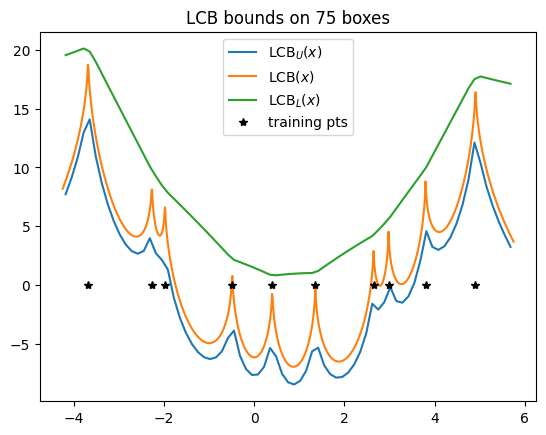

In [8]:
plt.plot(midpoints, LCB_Ls, label=r"LCB$_{U}(x)$")
plt.plot(X, Y_acqf, label=r'LCB$(x)$')
plt.plot(midpoints, LCB_Us, label=r"LCB$_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('LCB bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

In [9]:
from hiopbbpy.opt import minimizer_wrapper

In [10]:
acqf_callback = {'obj': acqf.scalar_evaluate}
acqf_callback['grad'] = acqf.scalar_eval_g
opt_solver = "SLSQP"
acqf_minimizer=minimizer_wrapper(acqf_callback, opt_solver, problem.xlimits, [], {})

In [11]:
from hiopbbpy.opt import BnBAlgorithm
bnb = BnBAlgorithm(x_train, y_train, gpsurrogate=gp_model, 
                   acqf_minimizer_callback=acqf_minimizer.minimizer_callback,
                   acquisition_type="LCB")
bnb.epsilon_diam = 1.e-4
bnb.epsilon_gap = 1.e-4

In [12]:
opt = bnb.optimize(problem.xlimits[:,0], problem.xlimits[:,1])

=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -47.340623923774075
Initial acquisition upper bound: -6.174132743142408

--- Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-47.340623923774075, U=-6.174132743142408
Current best feasible value (GUB): -6.174132743142408
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-31.58984805768003, U=8.180472922046675
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-31.519875018455984, U=-6.978493257909406
Queue size: 2 | GLB=-31.58984805768003 | GUB=-6.978493257909406 | Gap=24.611354799770623

--- Iteration 2 ---
Node bounds: l=[-4.25], u=[0.75]
Node acquisition bounds: L=-31.58984805768003, U=8.180472922046675
Current best feasible value (GUB): -6.978493257909406
  Branching to child: l=[-4.25], u=[-1.75]
  Child acquisition bounds: L=-12.89046850237106, U=4.1

  Child acquisition bounds: L=-7.250523676146451, U=-4.965975501799212
Queue size: 17 | GLB=-8.891304689739673 | GUB=-6.9784932579296175 | Gap=1.9128114318100558

--- Iteration 23 ---
Node bounds: l=[2.], u=[2.3125]
Node acquisition bounds: L=-8.891304689739673, U=-6.978493257929602
Current best feasible value (GUB): -6.9784932579296175
  Branching to child: l=[2.], u=[2.15625]
  Child acquisition bounds: L=-7.719965738049555, U=-6.53488985317044
  Branching to child: l=[2.15625], u=[2.3125]
  Child acquisition bounds: L=-6.890137460524101, U=-6.534889872571843
  Child pruned: L ≥ GUB - eps.
Queue size: 17 | GLB=-8.773759050073911 | GUB=-6.9784932579296175 | Gap=1.7952657921442938

--- Iteration 24 ---
Node bounds: l=[1.375], u=[1.6875]
Node acquisition bounds: L=-8.773759050073911, U=-6.534889845589448
Current best feasible value (GUB): -6.9784932579296175
  Branching to child: l=[1.375], u=[1.53125]
  Child acquisition bounds: L=-6.187748063591685, U=-6.534889872500893
  Child pruned

  Child acquisition bounds: L=-7.050625000929339, U=-6.978492998722369
  Branching to child: l=[1.140625], u=[1.21875]
  Child acquisition bounds: L=-6.3347036487459825, U=-6.97849325792961
  Child pruned: L ≥ GUB - eps.
Queue size: 24 | GLB=-7.5203602004883745 | GUB=-6.9784932579296175 | Gap=0.541866942558757

--- Iteration 41 ---
Node bounds: l=[0.984375], u=[1.0625]
Node acquisition bounds: L=-7.5203602004883745, U=-6.978493257929236
Current best feasible value (GUB): -6.9784932579296175
  Branching to child: l=[0.984375], u=[1.0234375]
  Child acquisition bounds: L=-7.151261101313147, U=-6.978493257929239
  Branching to child: l=[1.0234375], u=[1.0625]
  Child acquisition bounds: L=-6.961066277627091, U=-6.978493120543642
  Child pruned: L ≥ GUB - eps.
Queue size: 24 | GLB=-7.51397811080425 | GUB=-6.9784932579296175 | Gap=0.5354848528746325

--- Iteration 42 ---
Node bounds: l=[0.671875], u=[0.75]
Node acquisition bounds: L=-7.51397811080425, U=-6.978493257816772
Current best feasi

  Child acquisition bounds: L=-7.0900666263521765, U=-6.9784932500564745
Queue size: 23 | GLB=-7.205042733640389 | GUB=-6.9784932579296175 | Gap=0.22654947571077155

--- Iteration 58 ---
Node bounds: l=[0.84765625], u=[0.8671875]
Node acquisition bounds: L=-7.205042733640389, U=-6.978493257926779
Current best feasible value (GUB): -6.9784932579296175
  Branching to child: l=[0.84765625], u=[0.85742188]
  Child acquisition bounds: L=-7.089214965883907, U=-6.9784932557119435
  Branching to child: l=[0.85742188], u=[0.8671875]
  Child acquisition bounds: L=-7.092449031511344, U=-6.978493257809373
Queue size: 24 | GLB=-7.194382704995135 | GUB=-6.9784932579296175 | Gap=0.21588944706551771

--- Iteration 59 ---
Node bounds: l=[0.88671875], u=[0.90625]
Node acquisition bounds: L=-7.194382704995135, U=-6.978493257927117
Current best feasible value (GUB): -6.9784932579296175
  Branching to child: l=[0.88671875], u=[0.89648438]
  Child acquisition bounds: L=-7.084453348558175, U=-6.9784928252734

  Child acquisition bounds: L=-7.0237476841011475, U=-6.978493257573058
  Branching to child: l=[0.84277344], u=[0.84765625]
  Child acquisition bounds: L=-7.027614752227516, U=-6.978493245856625
Queue size: 31 | GLB=-7.075887951314157 | GUB=-6.9784932579296175 | Gap=0.09739469338453954

--- Iteration 78 ---
Node bounds: l=[0.89648438], u=[0.90625]
Node acquisition bounds: L=-7.075887951314157, U=-6.978493257885577
Current best feasible value (GUB): -6.9784932579296175
  Branching to child: l=[0.89648438], u=[0.90136719]
  Child acquisition bounds: L=-7.021118026540378, U=-6.978493257924794
  Branching to child: l=[0.90136719], u=[0.90625]
  Child acquisition bounds: L=-7.016075027567567, U=-6.978493257894592
Queue size: 32 | GLB=-7.073860281087088 | GUB=-6.9784932579296175 | Gap=0.09536702315747014

--- Iteration 79 ---
Node bounds: l=[0.828125], u=[0.83789062]
Node acquisition bounds: L=-7.073860281087088, U=-6.978493257020542
Current best feasible value (GUB): -6.9784932579296175
  

...

  Child acquisition bounds: L=-6.978195463064688, U=-6.978493257772906
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[0.86009216], u=[0.86016846]
  Child acquisition bounds: L=-6.978214904969675, U=-6.978493257781225
  Child pruned: L ≥ GUB - eps.
Queue size: 214 | GLB=-6.979251380238963 | GUB=-6.978493257929638 | Gap=0.0007581223093247047

--- Iteration 466 ---
Node bounds: l=[0.84765625], u=[0.8482666]
Node acquisition bounds: L=-6.979251380238963, U=-6.978493255522963
Current best feasible value (GUB): -6.978493257929638
  Branching to child: l=[0.84765625], u=[0.84796143]
  Child acquisition bounds: L=-6.975562515410271, U=-6.978493255581901
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[0.84796143], u=[0.8482666]
  Child acquisition bounds: L=-6.97575615773326, U=-6.978493255622404
  Child pruned: L ≥ GUB - eps.
Queue size: 213 | GLB=-6.979248646439831 | GUB=-6.978493257929638 | Gap=0.0007553885101927449

--- Iteration 467 ---
Node bounds: l=[0.88153076], u=[0.88

  Child acquisition bounds: L=-6.9781258365590375, U=-6.978493257528947
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[0.87672424], u=[0.87680054]
  Child acquisition bounds: L=-6.978105586027976, U=-6.978493257510026
  Child pruned: L ≥ GUB - eps.
Queue size: 146 | GLB=-6.979156292203893 | GUB=-6.978493257929638 | Gap=0.0006630342742548478

--- Iteration 534 ---
Node bounds: l=[0.87054443], u=[0.87062073]
Node acquisition bounds: L=-6.979156292203893, U=-6.978493257927767
Current best feasible value (GUB): -6.978493257929638
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 535 ---
Node bounds: l=[0.86581421], u=[0.8658905]
Node acquisition bounds: L=-6.979153694777234, U=-6.978493257928159
Current best feasible value (GUB): -6.978493257929638
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 536 ---
Node bounds: l=[0.87062073], u=[0.87069702]
Node acquisition bounds: L=-6.979150599953154, U=-6.978493257927541
Current best feasible value (GUB): -6.97

  Child acquisition bounds: L=-6.978012281939463, U=-6.978493257722957
  Child pruned: L ≥ GUB - eps.
Queue size: 108 | GLB=-6.97904791592096 | GUB=-6.978493257929638 | Gap=0.0005546579913220384

--- Iteration 572 ---
Node bounds: l=[0.8646698], u=[0.86474609]
Node acquisition bounds: L=-6.97904791592096, U=-6.978493257922739
Current best feasible value (GUB): -6.978493257929638
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 573 ---
Node bounds: l=[0.87176514], u=[0.87184143]
Node acquisition bounds: L=-6.979043375870153, U=-6.978493257919311
Current best feasible value (GUB): -6.978493257929638
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 574 ---
Node bounds: l=[0.86459351], u=[0.8646698]
Node acquisition bounds: L=-6.979039406969635, U=-6.978493257921901
Current best feasible value (GUB): -6.978493257929638
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 575 ---
Node bounds: l=[0.87184143], u=[0.87191772]
Node acquisition bounds: L=-6.

  Child acquisition bounds: L=-6.977825770362355, U=-6.978493257257155
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[0.87779236], u=[0.87786865]
  Child acquisition bounds: L=-6.977802972325099, U=-6.97849325723151
  Child pruned: L ≥ GUB - eps.
Queue size: 55 | GLB=-6.978855097503459 | GUB=-6.978493257929638 | Gap=0.00036183957382096565

--- Iteration 625 ---
Node bounds: l=[0.86322021], u=[0.86329651]
Node acquisition bounds: L=-6.978855097503459, U=-6.978493257904253
Current best feasible value (GUB): -6.978493257929638
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 626 ---
Node bounds: l=[0.88244629], u=[0.88275146]
Node acquisition bounds: L=-6.978850334210859, U=-6.978493253751424
Current best feasible value (GUB): -6.978493257929638
  Branching to child: l=[0.88244629], u=[0.88259888]
  Child acquisition bounds: L=-6.977090676126299, U=-6.978493253742864
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[0.88259888], u=[0.88275146]
  Child acquisit

  Child acquisition bounds: L=-6.977662362807625, U=-6.978493257069261
  Child pruned: L ≥ GUB - eps.
Queue size: 25 | GLB=-6.9787134065070955 | GUB=-6.978493257929638 | Gap=0.00022014857745755734

--- Iteration 655 ---
Node bounds: l=[0.86238098], u=[0.86245728]
Node acquisition bounds: L=-6.9787134065070955, U=-6.978493257883892
Current best feasible value (GUB): -6.978493257929638
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 656 ---
Node bounds: l=[0.88275146], u=[0.88305664]
Node acquisition bounds: L=-6.978711741950334, U=-6.978493253116963
Current best feasible value (GUB): -6.978493257929638
  Branching to child: l=[0.88275146], u=[0.88290405]
  Child acquisition bounds: L=-6.976952801613564, U=-6.978493253350257
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[0.88290405], u=[0.88305664]
  Child acquisition bounds: L=-6.976882772592088, U=-6.978493253217693
  Child pruned: L ≥ GUB - eps.
Queue size: 23 | GLB=-6.978706085277624 | GUB=-6.978493257929638 |

In [15]:
xstar_bounds = np.array([opt[0], opt[1]])
xstar = np.atleast_2d(np.mean(xstar_bounds, axis=0))
y_star = acqf.evaluate(xstar)

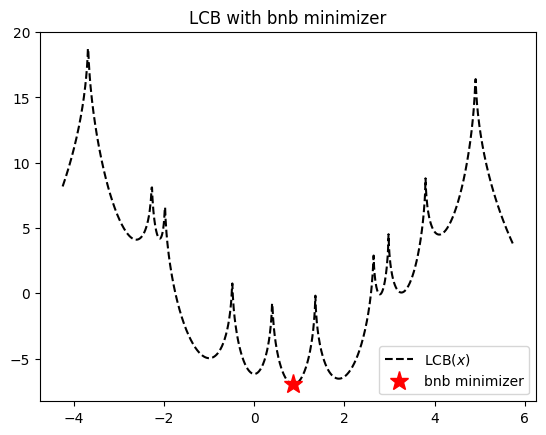

In [16]:
plt.plot(X, Y_acqf, 'k--', label=r'LCB$(x)$')
plt.plot(xstar, y_star, "r*", markersize=14, label=r'bnb minimizer')
#for i in range(2):
#    plt.plot(xstar_bounds.flatten()[i], y_star[0,0] , "k*")
plt.title('LCB with bnb minimizer'.format(nboxes))
plt.legend()
plt.show()

In [ ]:
options = {
    'acquisition_type': 'LCB',
    'acquisition_method' : 'bnb',
    'bo_maxiter': 10, 
    'batch_size': 1,
    'opt_solver': "SLSQP"    
}

In [ ]:
from hiopbbpy.opt import BOAlgorithm
bo = BOAlgorithm(problem, gp_model, x_train, y_train, options=options)

In [ ]:
bo.optimize()

In [ ]:
x_bo = bo.getOptimizationHistory()[0]
print(x_bo[i])

In [ ]:
x_train_superset = np.concatenate((x_train, x_bo), axis=0)
for i in range(x_bo.shape[0]):
    x_train2 = x_train_superset[:-10+i]
    y_train2 = problem.evaluate(x_train2)
    gp_model2 = smtKRG(theta, problem.xlimits, nx)
    gp_model2.train(x_train2, y_train2)
    acqf2 = LCBacquisition(gp_model2, beta=beta)
    Y_acqf2 = acqf2.evaluate(X)
    y_star2 = acqf2.evaluate(np.atleast_2d(x_bo[i]))
    plt.plot(X, Y_acqf2, label=r'$LCB(x)$')
    plt.plot(x_bo[i], y_star2, r'r*', markersize=12)
    #plt.plot(X, muX, "-.", label=r'$\mu(x)$')
    #plt.plot(X, sigmaX, label=r'$\sigma(x)$')
    plt.xlabel("x")
    plt.ylabel("LCB(x)")
    plt.legend()
    plt.title(r"LCB(x) at BO iteration {0:d}".format(i))
    plt.show()
    
    